In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
import numpy as np

project_root = Path.cwd().parent.parent
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# PyTorch
import torch
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

print(f"Using device: {device}")

# My own func (transform input datasets)
from lab3.src.utils.dataset import RawCovidDataset, TransformedDataset

# Augmentation
import albumentations  as A
from albumentations.pytorch import ToTensorV2

Using device: cuda


In [2]:
image_size = (224, 224)
train_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.CLAHE(p=1.0), 
    A.Affine(rotate=(-15, 15)),
    A.HorizontalFlip(p=0.5),
    A.Normalize(   
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    ToTensorV2(),
])

test_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    ToTensorV2(),
])

In [3]:
full_dataset = RawCovidDataset()

train_share = 0.85
val_share = 0.15

generator = torch.Generator().manual_seed(42)

train_sub, val_sub = random_split(
    full_dataset, 
    [train_share, val_share], 
    generator=generator
)

train_dataset = TransformedDataset(train_sub, transform=train_transforms)
val_dataset = TransformedDataset(val_sub, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Берём модель случайного леса

In [4]:
from sklearn.ensemble import RandomForestClassifier
   
model = RandomForestClassifier()

def collect_data(dataloader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    x_list = []
    y_list = []
    
    for batch in dataloader:
        inputs, targets = batch
        
        inputs: torch.Tensor
        targets: torch.Tensor
        
        x_flat = inputs.view(inputs.size(0), -1)
        x_list.append(x_flat)
        y_list.append(targets)
        
    x_full = torch.cat(x_list, dim=0).cpu().numpy()
    y_full = torch.cat(y_list, dim=0).cpu().numpy()
    
    return x_full, y_full

Обучение

In [5]:
X_train, y_train = collect_data(train_loader)
X_val, y_val = collect_data(val_loader)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Метрики


Classification Report:
              precision    recall  f1-score   support

   non-COVID       0.64      0.94      0.76       196
       COVID       0.87      0.40      0.55       176

    accuracy                           0.69       372
   macro avg       0.75      0.67      0.66       372
weighted avg       0.75      0.69      0.66       372


Confusion Matrix:
[[185  11]
 [105  71]]


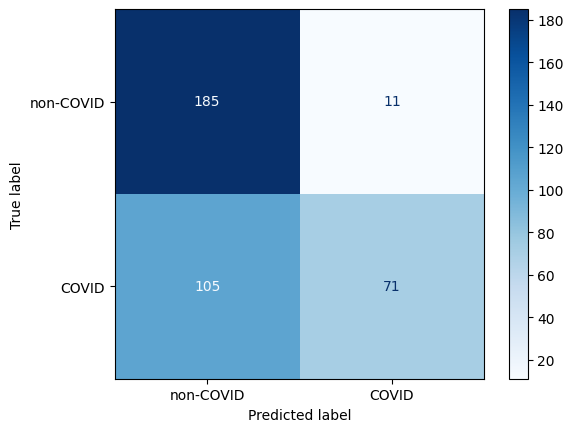

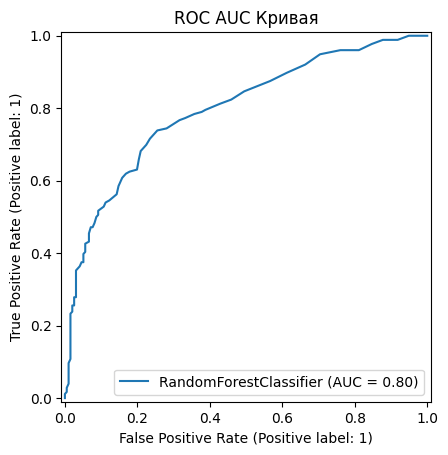

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
   classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

target_names = [class_name for class_name, idx in sorted(full_dataset.class_to_idx.items(), key=lambda item: item[1])]

y_pred = model.predict(X_val)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, zero_division=0, target_names=target_names))

#  Confustion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(
	confusion_matrix=cm,
	display_labels=target_names,
)
disp.plot(cmap="Blues")

#  ROC-AUC plot
RocCurveDisplay.from_estimator(model, X_val, y_val)

plt.title("ROC AUC Кривая")
plt.show()

Подбор порога

In [10]:
THRESHOLD = 0.1

rf_probs = model.predict_proba(X_val)[:, 1]

y_pred_rf = (rf_probs >= THRESHOLD).astype(int)
print(classification_report(y_val, y_pred_rf, target_names=target_names))

              precision    recall  f1-score   support

   non-COVID       0.82      0.34      0.48       196
       COVID       0.55      0.92      0.69       176

    accuracy                           0.61       372
   macro avg       0.69      0.63      0.59       372
weighted avg       0.70      0.61      0.58       372

